# Thesis: Reclaimed Timber in Deep Generative Design
**Notebook ID:** c21_surrogate_model_training  
**Author:** Jasper Cluistra   
**Last Updated:** 2026-03-19
 o### Surrogate model training script
**Goal:** Train a surrogate model on a CSV dataset produced by Grasshopper structural analyses. The model should predict whether a beam in the structure fails structurally.
**Inputs:**
*   CSV with structural properties from Grasshopper

**Outputs:**
*   Trained surrogate model

# PARAMETERS

In [ ]:
import config
from naming import build_run_id

CSV_FILE = 'v3.1_F65_T32_S10000_D20260402.csv'
print(f"Active dataset: {CSV_FILE}")

# ============================================
# WORKFLOW TOGGLE: train from scratch OR use a pre-trained model
# ============================================
USE_PRETRAINED = False  # Set to True to load a pre-trained model instead of training
PRETRAINED_MODEL_PREFIX = "data_4_0000"  # Legacy fallback: set this to a full artifact stem when reusing a trained model

# Training runtime options (only used if USE_PRETRAINED=False)
USE_TRAINING_TIME_LIMIT = False  # Set to True for short test runs
TRAINING_TIME_LIMIT_SECONDS = 60

# Core training hyperparameters
LEARNING_RATE = 0.0005
EPOCHS = 100
TRAIN_SPLIT_RATIO = 0.8
RANDOM_SEED = 42

# Run identity used across model artifacts and evaluation exports
RUN_ID = build_run_id()
print(f"Run ID: {RUN_ID}")


Active dataset: data_3.1.csv


# IMPORTING DATA

In [ ]:
import config
import pandas as pd
import torch
import json
import re

from naming import build_dataset_filename, build_dataset_label, infer_dataset_version

print("1. Loading dataset...")
df = pd.read_csv(config.GH_DATA_PATH / CSV_FILE)
print(f"✅ Dataset '{CSV_FILE}' loaded.")

with open(config.DATA_IO_PATH / 'edge_index.json', 'r') as f:
    edge_index = torch.tensor(json.load(f), dtype=torch.long)

# 2. Hard validation of dimensions
print("\n--- DATA VALIDATION ---")
print(f"Number of samples (rows) in dataset: {len(df)}")
print(f"Total number of columns in dataset: {df.shape[1]}")
print(f"Shape of the edge_index tensor: {edge_index.shape}")

# Dynamically infer node and edge counts from the data
NODE_IDS = sorted({int(m.group(1)) for col in df.columns if (m := re.match(r'^v(\d+)_x$', col))})
assert NODE_IDS, "Error: no node coordinates found in CSV (expected columns like v0_x)."
NODE_COUNT = len(NODE_IDS)

EDGE_COLS = sorted(
    [col for col in df.columns if re.match(r'^beam\d+_a_force$', col)],
    key=lambda c: int(re.match(r'^beam(\d+)_a_force$', c).group(1))
)
EDGE_COUNT = len(EDGE_COLS)

# Quick sanity check: detect automatically whether support/load features are present
for i in NODE_IDS:
    assert f"v{i}_y" in df.columns and f"v{i}_z" in df.columns, f"Error: missing y/z columns for vertex v{i}."

has_support_cols = all(f"v{i}_is_support" in df.columns for i in NODE_IDS)
has_load_cols = all(f"v{i}_load_z" in df.columns for i in NODE_IDS)
assert has_support_cols == has_load_cols, "Error: incomplete node features. Expected both is_support and load_z per vertex."
NODE_FEATURE_DIM = 5 if (has_support_cols and has_load_cols) else 3
expected_columns = 1 + (NODE_COUNT * NODE_FEATURE_DIM) + EDGE_COUNT  # +1 for sample_id
assert df.shape[1] == expected_columns, f"Error: CSV has {df.shape[1]} columns, expected {expected_columns} based on schema."
assert edge_index.shape[0] == 2, "Error: edge_index must have exactly 2 rows (source and target nodes)."
assert edge_index.shape[1] == EDGE_COUNT, f"Error: edge_index must have exactly {EDGE_COUNT} columns (connections)."

DATASET_VERSION = infer_dataset_version(CSV_FILE)
STRICT_DATASET_LABEL = build_dataset_label(DATASET_VERSION, NODE_COUNT * NODE_FEATURE_DIM, EDGE_COUNT, len(df))
STRICT_DATASET_FILENAME = build_dataset_filename(DATASET_VERSION, NODE_COUNT * NODE_FEATURE_DIM, EDGE_COUNT, len(df))
print(f"Structured dataset label: {STRICT_DATASET_LABEL}")
print(f"Expected strict filename: {STRICT_DATASET_FILENAME}")
if not CSV_FILE.startswith(f"{STRICT_DATASET_LABEL}_") and STRICT_DATASET_FILENAME != CSV_FILE:
    print(f"Legacy source filename in use: {CSV_FILE}")

print(f"Detected node count: {NODE_COUNT}")
print(f"Detected edge count: {EDGE_COUNT}")
print(f"Detected node feature dim: {NODE_FEATURE_DIM}")
print("Validation successful. Data loaded correctly.")


1. Loading dataset...
✅ Dataset 'data_3.1.csv' loaded.

--- DATA VALIDATION ---
Number of samples (rows) in dataset: 10000
Total number of columns in dataset: 98
Shape of the edge_index tensor: torch.Size([2, 32])
Detected node count: 13
Detected edge count: 32
Detected node feature dim: 5
Validation successful. Data loaded correctly.


# PROCESSING DATA

In [ ]:
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.preprocessing import StandardScaler
import numpy as np
import os

# 1. Set up normalization
# Neural networks work best with values around 0.
print("Starting data normalization...")
node_scaler = StandardScaler()
edge_scaler = StandardScaler()

# Build column names in advance
if NODE_FEATURE_DIM == 5:
    # For data_4: x, y, z, load_z, and is_support per vertex
    node_cols = [f"v{i}_{feat}" for i in NODE_IDS for feat in ("x", "y", "z", "load_z", "is_support")]
else:
    node_cols = [f"v{i}_{axis}" for i in NODE_IDS for axis in ("x", "y", "z")]
edge_cols = EDGE_COLS

# 2. Fetch raw data in one vectorized step and rescale it
node_raw = df[node_cols].to_numpy(dtype=np.float32).reshape(-1, NODE_COUNT, NODE_FEATURE_DIM)
edge_raw = df[edge_cols].to_numpy(dtype=np.float32).reshape(-1, EDGE_COUNT, 1)

if NODE_FEATURE_DIM == 5:
    # Scale only continuous features; keep binary support feature at 0/1
    node_continuous = node_raw[:, :, :4]
    node_support = node_raw[:, :, 4:5]
    node_scaler.fit(node_continuous.reshape(-1, 4))
    node_continuous_scaled = node_scaler.transform(node_continuous.reshape(-1, 4)).reshape(-1, NODE_COUNT, 4)
    node_scaled = np.concatenate([node_continuous_scaled, node_support], axis=2)
else:
    node_scaler.fit(node_raw.reshape(-1, 3))
    node_scaled = node_scaler.transform(node_raw.reshape(-1, 3)).reshape(-1, NODE_COUNT, 3)
edge_scaler.fit(edge_raw.reshape(-1, 1))

edge_scaled = edge_scaler.transform(edge_raw.reshape(-1, 1)).reshape(-1, EDGE_COUNT, 1)

# 3. Build dataset with the normalized data
print("Building graph objects...")
graph_dataset = [
    Data(
        x=torch.from_numpy(node_scaled[i]),
        edge_index=edge_index,
        y_edge=torch.from_numpy(edge_scaled[i])
    )
    for i in range(len(df))
]

# 4. Split into Train (80%) and Test (20%) with a fixed seed for reproducibility
rng = np.random.default_rng(RANDOM_SEED)
indices = rng.permutation(len(graph_dataset))
train_size = int(TRAIN_SPLIT_RATIO * len(graph_dataset))
train_idx = indices[:train_size]
test_idx = indices[train_size:]

train_dataset = [graph_dataset[i] for i in train_idx]
test_dataset = [graph_dataset[i] for i in test_idx]

# 5. Tune DataLoaders for a more efficient input pipeline
loader_kwargs = {
    "batch_size": 32,
    "num_workers": min(4, os.cpu_count() or 1),
    "pin_memory": torch.cuda.is_available()
}
if loader_kwargs["num_workers"] > 0:
    loader_kwargs["persistent_workers"] = True

train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

print(f"Dataset ready! Train set: {len(train_dataset)} graphs. Test set: {len(test_dataset)} graphs.")


c:\Users\jaspe\Documents\PyEnvs\thesis_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Starting data normalization...
Building graph objects...
Dataset ready! Train set: 8000 graphs. Test set: 2000 graphs.


# MODEL SETUP

In [ ]:
from c21_surrogate_model import TrussEdgeGNN
import torch
import joblib

# Reset the model on your device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if USE_PRETRAINED:
    # Load pre-trained model
    print(f"\n🔄 LOADING PRE-TRAINED MODEL: {PRETRAINED_MODEL_PREFIX}")
    checkpoint_path = config.SM_EXPORT_PATH / f"{PRETRAINED_MODEL_PREFIX}_surrogate_model.pt"
    if not checkpoint_path.exists():
        checkpoint_path = config.SM_EXPORT_PATH / f"truss_edge_gnn_{PRETRAINED_MODEL_PREFIX}.pt"
    checkpoint = torch.load(checkpoint_path, map_location=device)
    node_in_dim = checkpoint.get('node_in_dim', 3) if isinstance(checkpoint, dict) else 3
    hidden_dim = checkpoint.get('hidden_dim', 128) if isinstance(checkpoint, dict) else 128
    model = TrussEdgeGNN(node_in_dim=node_in_dim, hidden_dim=hidden_dim).to(device)
    model.load_state_dict(checkpoint['model_state_dict'] if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint else checkpoint)
    
    # Load pre-trained scalers
    node_scaler_path = config.SM_EXPORT_PATH / f"{PRETRAINED_MODEL_PREFIX}_node_scaler.pkl"
    edge_scaler_path = config.SM_EXPORT_PATH / f"{PRETRAINED_MODEL_PREFIX}_edge_scaler.pkl"
    if not node_scaler_path.exists():
        node_scaler_path = config.SM_EXPORT_PATH / f"node_scaler_{PRETRAINED_MODEL_PREFIX}.pkl"
        edge_scaler_path = config.SM_EXPORT_PATH / f"edge_scaler_{PRETRAINED_MODEL_PREFIX}.pkl"
    node_scaler = joblib.load(node_scaler_path)
    edge_scaler = joblib.load(edge_scaler_path)
    
    print("Pre-trained model and scalers loaded.")
else:
    print("Training from scratch.")
    model = TrussEdgeGNN(node_in_dim=NODE_FEATURE_DIM, hidden_dim=128).to(device)


Training from scratch.


# MODEL TRAINING

In [ ]:
from sklearn.metrics import r2_score
import time

# Initialize history containers so plotting works in both modes
epoch_history = []
train_loss_history = []
final_val_r2 = None

# Skip training if using pre-trained model
if USE_PRETRAINED:
    print("\n⏭️  SKIPPING TRAINING (using pre-trained model)")
else:
    print("\n🚀 STARTING TRAINING...\n")
    
    # ==========================================
    # 1. SETUP VAN DE OPTIMIZER EN LOSS FUNCTIE
    # ==========================================
    # lr=0.001 is je startwaarde. Pas deze aan als de Loss explodeert of stagneert.
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = torch.optim.Adam(model.parameters(), lr=0.00001)

    # Mean Squared Error (MSE) is de standaard voor regressie (het voorspellen van continue getallen)
    criterion = torch.nn.MSELoss()

    EVAL_EVERY = 10
    train_start_time = time.time()

    if USE_TRAINING_TIME_LIMIT:
        print(f"Start training voor {EPOCHS} epochs (max {TRAINING_TIME_LIMIT_SECONDS}s)...\n")
    else:
        print(f"Start training voor {EPOCHS} epochs (zonder tijdslimiet)...\n")

    # ==========================================
    # 2. DE TRAINING LOOP
    # ==========================================
    for epoch in range(EPOCHS):
        if USE_TRAINING_TIME_LIMIT:
            elapsed = time.time() - train_start_time
            if elapsed >= TRAINING_TIME_LIMIT_SECONDS:
                print(f"Stop training na {elapsed:.1f}s (tijdslimiet bereikt).")
                break

        model.train() # Zet model in trainingsmodus
        total_loss = 0.0

        # Loop over alle batches in de trainingsdata
        for batch in train_loader:
            batch = batch.to(device, non_blocking=True)

            # Reset de gradiënten (wiskundige stappen) van de vorige iteratie
            optimizer.zero_grad(set_to_none=True)

            # Forward pass: Laat het model voorspellen
            out = model(batch.x, batch.edge_index)

            # Bereken de fout (Loss)
            loss = criterion(out, batch.y_edge)

            # Backward pass: Bereken hoe de gewichten moeten veranderen
            loss.backward()

            # Optimizer step: Pas de gewichten daadwerkelijk aan
            optimizer.step()

            # Tel de loss op voor de statistieken
            total_loss += loss.item() * batch.num_graphs

        avg_train_loss = total_loss / len(train_dataset)
        epoch_history.append(epoch + 1)
        train_loss_history.append(avg_train_loss)

        # ==========================================
        # 3. DE EVALUATIE LOOP (Elke EVAL_EVERY epochs)
        # ==========================================
        if (epoch + 1) % EVAL_EVERY == 0:
            model.eval() # Zet model in testmodus (geen gewichten aanpassen)
            pred_batches = []
            true_batches = []

            with torch.no_grad(): # Bespaar geheugen, we trainen hier niet
                for batch in test_loader:
                    batch = batch.to(device, non_blocking=True)
                    out = model(batch.x, batch.edge_index)

                    pred_batches.append(out.detach().cpu())
                    true_batches.append(batch.y_edge.detach().cpu())

            preds_scaled = torch.cat(pred_batches, dim=0).numpy()
            trues_scaled = torch.cat(true_batches, dim=0).numpy()

            # Transformeer de geschaalde getallen terug naar echte kiloNewtons (kN)
            preds_original = edge_scaler.inverse_transform(preds_scaled)
            trues_original = edge_scaler.inverse_transform(trues_scaled)

            # Bereken de R2 score op de echte (ongeziene) test data
            r2 = r2_score(trues_original, preds_original)
            final_val_r2 = float(r2)
            print(f"Epoch {epoch+1:03d}/{EPOCHS} | Train Loss (Genormaliseerd): {avg_train_loss:.4f} | Test R2 Score: {r2:.4f}")

    if final_val_r2 is None:
        with torch.no_grad():
            pred_batches = []
            true_batches = []
            for batch in test_loader:
                batch = batch.to(device, non_blocking=True)
                out = model(batch.x, batch.edge_index)
                pred_batches.append(out.detach().cpu())
                true_batches.append(batch.y_edge.detach().cpu())
            preds_scaled = torch.cat(pred_batches, dim=0).numpy()
            trues_scaled = torch.cat(true_batches, dim=0).numpy()
            final_val_r2 = float(r2_score(edge_scaler.inverse_transform(trues_scaled), edge_scaler.inverse_transform(preds_scaled)))

    print("\nTraining afgerond! Je Graph Neural Network is klaar voor gebruik in je workflow.")



🚀 STARTING TRAINING...

Start training voor 100 epochs (zonder tijdslimiet)...

Epoch 010/100 | Train Loss (Genormaliseerd): 0.1536 | Test R2 Score: 0.8383
Epoch 020/100 | Train Loss (Genormaliseerd): 0.1207 | Test R2 Score: 0.8697
Epoch 030/100 | Train Loss (Genormaliseerd): 0.1098 | Test R2 Score: 0.8815
Epoch 040/100 | Train Loss (Genormaliseerd): 0.1023 | Test R2 Score: 0.8832
Epoch 050/100 | Train Loss (Genormaliseerd): 0.0964 | Test R2 Score: 0.8867
Epoch 060/100 | Train Loss (Genormaliseerd): 0.0923 | Test R2 Score: 0.8884
Epoch 070/100 | Train Loss (Genormaliseerd): 0.0887 | Test R2 Score: 0.8909
Epoch 080/100 | Train Loss (Genormaliseerd): 0.0861 | Test R2 Score: 0.8938
Epoch 090/100 | Train Loss (Genormaliseerd): 0.0824 | Test R2 Score: 0.8928
Epoch 100/100 | Train Loss (Genormaliseerd): 0.0803 | Test R2 Score: 0.8944

Training afgerond! Je Graph Neural Network is klaar voor gebruik in je workflow.


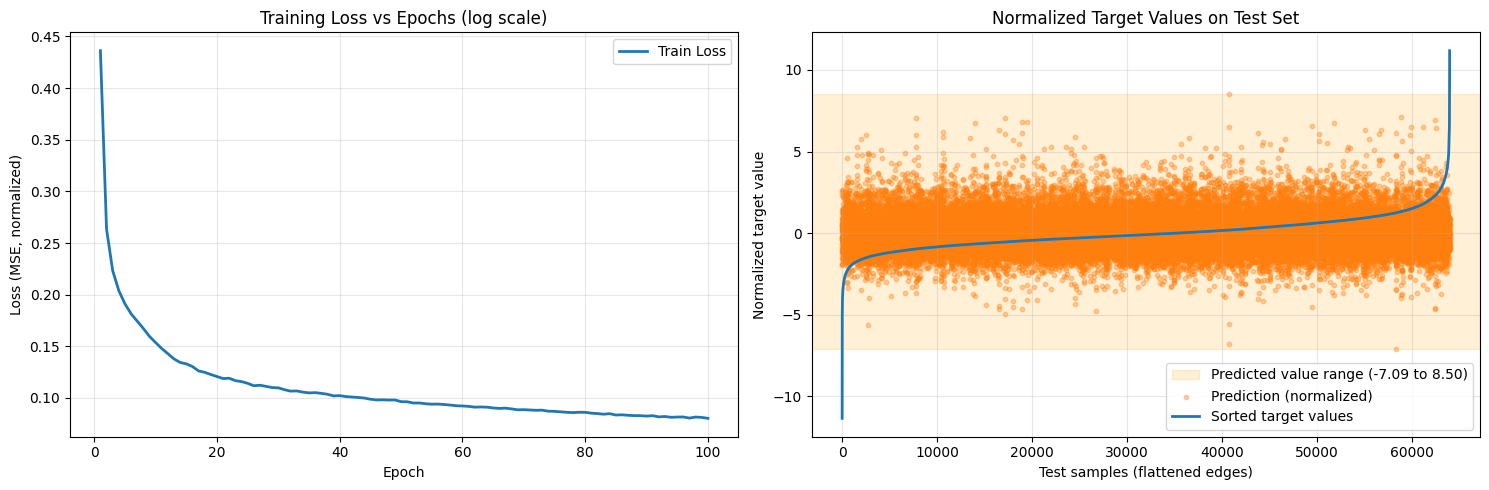

✅ Training visualizations generated.


In [27]:
# TRAINING VISUALS: Loss curve + normalized target distribution on test set
import matplotlib.pyplot as plt
import numpy as np
import torch

# Graceful fallbacks when cell is run in a fresh kernel
epoch_history_local = globals().get("epoch_history", [])
train_loss_history_local = globals().get("train_loss_history", [])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1) Loss vs Epochs (log scale for readability)
ax = axes[0]
if len(epoch_history_local) > 0 and len(train_loss_history_local) > 0:
    ax.plot(epoch_history_local, train_loss_history_local, color='tab:blue', linewidth=2, label='Train Loss')
    ax.set_yscale('linear')
    ax.set_title('Training Loss vs Epochs (log scale)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE, normalized)')
    ax.grid(True, alpha=0.3)
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No training history in memory\nRun training cell first', ha='center', va='center')
    ax.set_title('Training Loss vs Epochs')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE, normalized)')
    ax.grid(True, alpha=0.3)

# 2) Normalized target values vs test sample index + sorted target line
required = ['model', 'test_loader', 'device']
if all(name in globals() for name in required):
    model.eval()
    all_test_targets_scaled = []
    all_test_preds_scaled = []

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device, non_blocking=True)
            out = model(batch.x, batch.edge_index)
            all_test_targets_scaled.append(batch.y_edge.detach().cpu().numpy().reshape(-1))
            all_test_preds_scaled.append(out.detach().cpu().numpy().reshape(-1))

    if len(all_test_targets_scaled) > 0:
        target_values = np.concatenate(all_test_targets_scaled)
        pred_values = np.concatenate(all_test_preds_scaled)
        sample_idx = np.arange(target_values.shape[0])

        ax = axes[1]

        # Vertical value range band based on full predicted range
        band_min = float(pred_values.min())
        band_max = float(pred_values.max())
        ax.axhspan(
            band_min,
            band_max,
            color='orange',
            alpha=0.16,
            zorder=0,
            label=f'Predicted value range ({band_min:.2f} to {band_max:.2f})'
        )

        ax.scatter(sample_idx, pred_values, s=10, alpha=0.35, color='tab:orange', label='Prediction (normalized)')
        ax.plot(sample_idx, np.sort(target_values), color='tab:blue', linewidth=2, label='Sorted target values')
        ax.set_title('Normalized Target Values on Test Set')
        ax.set_xlabel('Test samples (flattened edges)')
        ax.set_ylabel('Normalized target value')
        ax.grid(True, alpha=0.3)
        ax.legend()
    else:
        axes[1].text(0.5, 0.5, 'No test batches available', ha='center', va='center')
        axes[1].set_title('Normalized Target Values on Test Set')
        axes[1].set_xlabel('Test samples (flattened edges)')
        axes[1].set_ylabel('Normalized target value')
        axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'Missing model/test data in memory\nRun setup + training cells first', ha='center', va='center')
    axes[1].set_title('Normalized Target Values on Test Set')
    axes[1].set_xlabel('Test samples (flattened edges)')
    axes[1].set_ylabel('Normalized target value')
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
training_visuals_fig = fig  # Capture figure reference for evaluation export
plt.show()

print('✅ Training visualizations generated.')

# EXPORT

In [ ]:
import json
import joblib
import torch

from naming import build_model_artifact_stem

# Only export if training from scratch (not loading pre-trained)
if USE_PRETRAINED:
    print("\n⏭️  SKIPPING EXPORT (using pre-trained model)")
else:
    print("\n💾 EXPORTING MODEL AND SCALERS...\n")

    artifact_stem = build_model_artifact_stem(RUN_ID, LEARNING_RATE, EPOCHS, final_val_r2)

    # Save the active stem for downstream inference and tracing
    with open(config.SM_EXPORT_PATH / 'prefix_sm.txt', 'w', encoding='utf-8') as f:
        f.write(artifact_stem)

    run_manifest = {
        "run_id": RUN_ID,
        "artifact_stem": artifact_stem,
        "dataset_source": CSV_FILE,
        "strict_dataset_label": STRICT_DATASET_LABEL,
        "learning_rate": LEARNING_RATE,
        "epochs": EPOCHS,
        "final_val_r2": final_val_r2,
        "node_count": NODE_COUNT,
        "edge_count": EDGE_COUNT,
        "node_feature_dim": NODE_FEATURE_DIM,
    }

    # Export the scalers used by this notebook
    node_scaler_path = config.SM_EXPORT_PATH / f"{artifact_stem}_node_scaler.pkl"
    edge_scaler_path = config.SM_EXPORT_PATH / f"{artifact_stem}_edge_scaler.pkl"
    joblib.dump(node_scaler, node_scaler_path)
    joblib.dump(edge_scaler, edge_scaler_path)

    print(f"Scalers successfully saved:\n- {node_scaler_path}\n- {edge_scaler_path}")

    # Export the trained GNN model as a state_dict checkpoint
    model_path = config.SM_EXPORT_PATH / f"{artifact_stem}_surrogate_model.pt"
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "node_in_dim": NODE_FEATURE_DIM,
            "hidden_dim": 128,
            "edge_count": EDGE_COUNT,
            "checkpoint_prefix": artifact_stem,
            "run_id": RUN_ID,
            "dataset_source": CSV_FILE,
            "strict_dataset_label": STRICT_DATASET_LABEL,
            "learning_rate": LEARNING_RATE,
            "epochs": EPOCHS,
            "final_val_r2": final_val_r2,
        },
        model_path
    )

    manifest_path = config.SM_EXPORT_PATH / f"{artifact_stem}_run_manifest.json"
    with open(manifest_path, 'w', encoding='utf-8') as f:
        json.dump(run_manifest | {"model_path": model_path.name, "node_scaler_path": node_scaler_path.name, "edge_scaler_path": edge_scaler_path.name}, f, indent=2)

    print(f"\nModel checkpoint successfully saved:\n- {model_path}")
    print(f"Run manifest saved:\n- {manifest_path}")



💾 EXPORTING MODEL AND SCALERS...

Scalers succesvol opgeslagen:
- C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\01_surrogate_models\node_scaler_data_3.1_0000.pkl
- C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\01_surrogate_models\edge_scaler_data_3.1_0000.pkl

Model checkpoint succesvol opgeslagen:
- C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\01_surrogate_models\truss_edge_gnn_data_3.1_0000.pt


# EVALUATION & VISUALIZATION FOR OVER/UNDERFITTING

In [10]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from model_evaluation import save_evaluation, print_evaluation_metrics

print("Collecting predictions for visualization...")

Train R2:  0.9221
Test R2:   0.8944
Train MAE: 4.1887 kN
Test MAE:  4.6190 kN
Status:    good_fit


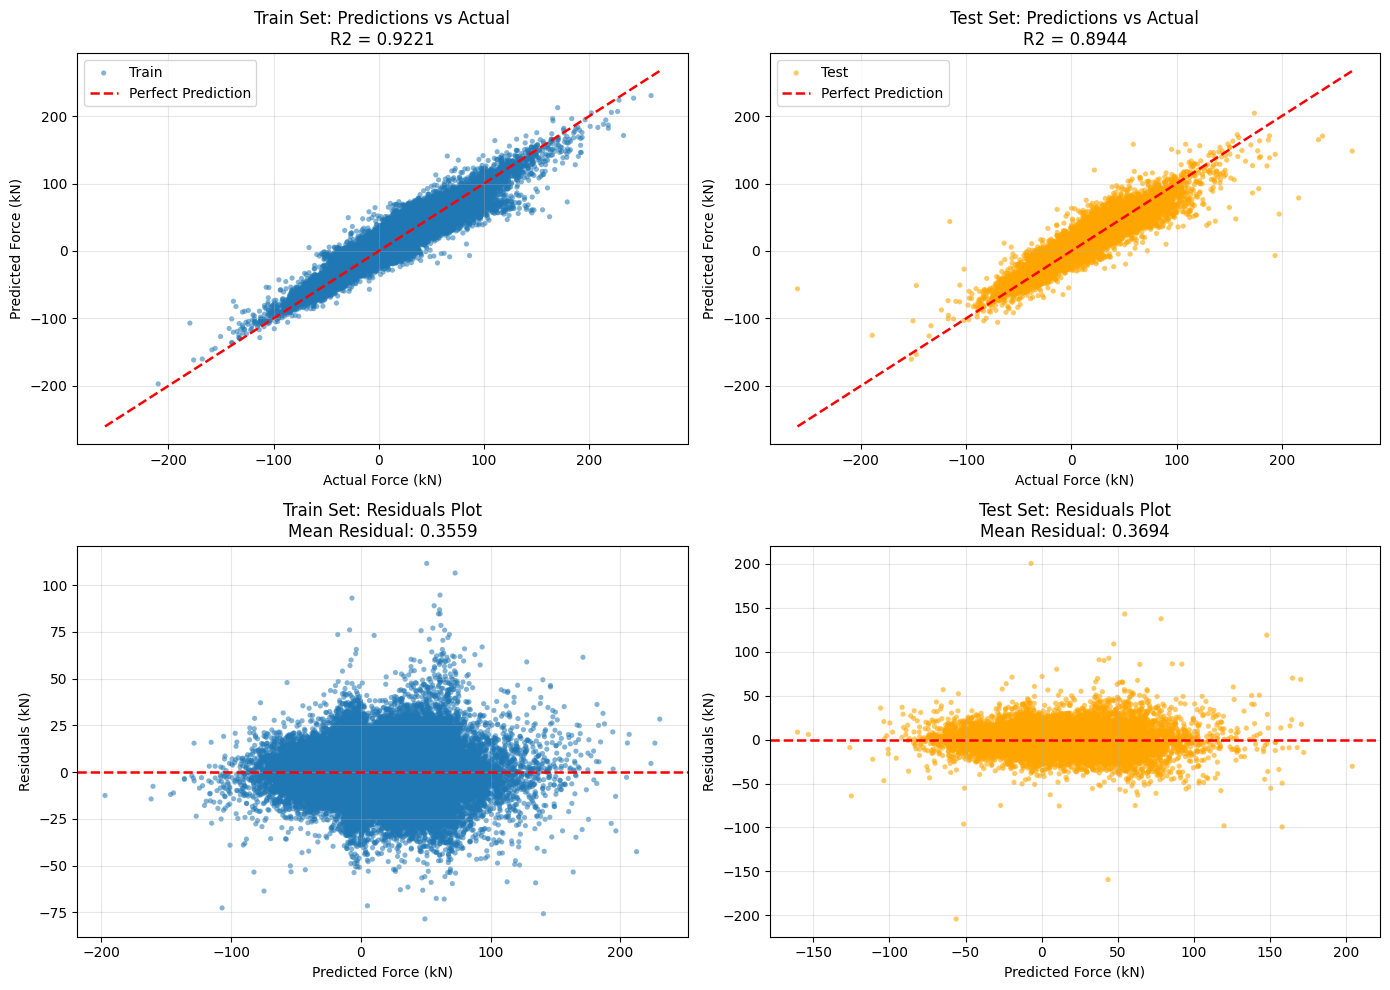

✅ Prediction/residual diagnostic plots generated.


In [28]:
# Predictions vs Actual + Residual diagnostics (Train/Test)
required_objs = ["model", "device", "edge_scaler", "train_loader", "test_loader"]
missing_objs = [name for name in required_objs if name not in globals()]
if missing_objs:
    raise NameError(f"Missing required objects in memory: {missing_objs}. Run setup/training cells first.")

def _collect_preds_trues_original(loader):
    model.eval()
    pred_batches_local = []
    true_batches_local = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device, non_blocking=True)
            out = model(batch.x, batch.edge_index)
            pred_batches_local.append(out.detach().cpu().numpy())
            true_batches_local.append(batch.y_edge.detach().cpu().numpy())

    preds_scaled_local = np.concatenate(pred_batches_local, axis=0)
    trues_scaled_local = np.concatenate(true_batches_local, axis=0)

    preds_original_local = edge_scaler.inverse_transform(preds_scaled_local).reshape(-1)
    trues_original_local = edge_scaler.inverse_transform(trues_scaled_local).reshape(-1)
    return preds_original_local, trues_original_local

# Collect predictions and targets in original kN scale
train_preds_original, train_trues_original = _collect_preds_trues_original(train_loader)
test_preds_original, test_trues_original = _collect_preds_trues_original(test_loader)

# Residuals and metrics
train_residuals = train_trues_original - train_preds_original
test_residuals = test_trues_original - test_preds_original

train_mae = float(mean_absolute_error(train_trues_original, train_preds_original))
test_mae = float(mean_absolute_error(test_trues_original, test_preds_original))
train_rmse = float(np.sqrt(mean_squared_error(train_trues_original, train_preds_original)))
test_rmse = float(np.sqrt(mean_squared_error(test_trues_original, test_preds_original)))
train_r2 = float(r2_score(train_trues_original, train_preds_original))
test_r2 = float(r2_score(test_trues_original, test_preds_original))

# Build status label for quick interpretation
r2_gap = train_r2 - test_r2
if train_r2 < 0.7 and test_r2 < 0.7:
    status = "underfitting"
elif r2_gap > 0.05:
    status = "overfitting"
else:
    status = "good_fit"

model_prefix = globals().get("prefix_sm", globals().get("PRETRAINED_MODEL_PREFIX", "unknown_model"))
metrics = {
    "train_r2": train_r2,
    "test_r2": test_r2,
    "train_mae": train_mae,
    "test_mae": test_mae,
    "train_rmse": train_rmse,
    "test_rmse": test_rmse,
    "r2_gap": float(r2_gap),
}

# Print concise metric summary
print(f"Train R2:  {train_r2:.4f}")
print(f"Test R2:   {test_r2:.4f}")
print(f"Train MAE: {train_mae:.4f} kN")
print(f"Test MAE:  {test_mae:.4f} kN")
print(f"Status:    {status}")

# 2x2 plot: Pred vs Actual + residuals for Train/Test
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Shared limits for prediction-vs-actual plots
all_trues = np.concatenate([train_trues_original, test_trues_original])
all_preds = np.concatenate([train_preds_original, test_preds_original])
lim_low = min(all_trues.min(), all_preds.min())
lim_high = max(all_trues.max(), all_preds.max())

# Top-left: Train Pred vs Actual
ax = axes[0, 0]
ax.scatter(train_trues_original, train_preds_original, s=14, alpha=0.55, color="tab:blue", edgecolors="none", label="Train")
ax.plot([lim_low, lim_high], [lim_low, lim_high], "r--", linewidth=1.8, label="Perfect Prediction")
ax.set_title(f"Train Set: Predictions vs Actual\nR2 = {train_r2:.4f}")
ax.set_xlabel("Actual Force (kN)")
ax.set_ylabel("Predicted Force (kN)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")

# Top-right: Test Pred vs Actual
ax = axes[0, 1]
ax.scatter(test_trues_original, test_preds_original, s=14, alpha=0.60, color="orange", edgecolors="none", label="Test")
ax.plot([lim_low, lim_high], [lim_low, lim_high], "r--", linewidth=1.8, label="Perfect Prediction")
ax.set_title(f"Test Set: Predictions vs Actual\nR2 = {test_r2:.4f}")
ax.set_xlabel("Actual Force (kN)")
ax.set_ylabel("Predicted Force (kN)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")

# Bottom-left: Train residuals vs predicted
ax = axes[1, 0]
ax.scatter(train_preds_original, train_residuals, s=14, alpha=0.55, color="tab:blue", edgecolors="none")
ax.axhline(0, color="red", linestyle="--", linewidth=1.8)
ax.set_title(f"Train Set: Residuals Plot\nMean Residual: {np.mean(train_residuals):.4f}")
ax.set_xlabel("Predicted Force (kN)")
ax.set_ylabel("Residuals (kN)")
ax.grid(True, alpha=0.3)

# Bottom-right: Test residuals vs predicted
ax = axes[1, 1]
ax.scatter(test_preds_original, test_residuals, s=14, alpha=0.60, color="orange", edgecolors="none")
ax.axhline(0, color="red", linestyle="--", linewidth=1.8)
ax.set_title(f"Test Set: Residuals Plot\nMean Residual: {np.mean(test_residuals):.4f}")
ax.set_xlabel("Predicted Force (kN)")
ax.set_ylabel("Residuals (kN)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
pred_residuals_fig = fig  # Used later by save_evaluation(...)
plt.show()

print("✅ Prediction/residual diagnostic plots generated.")

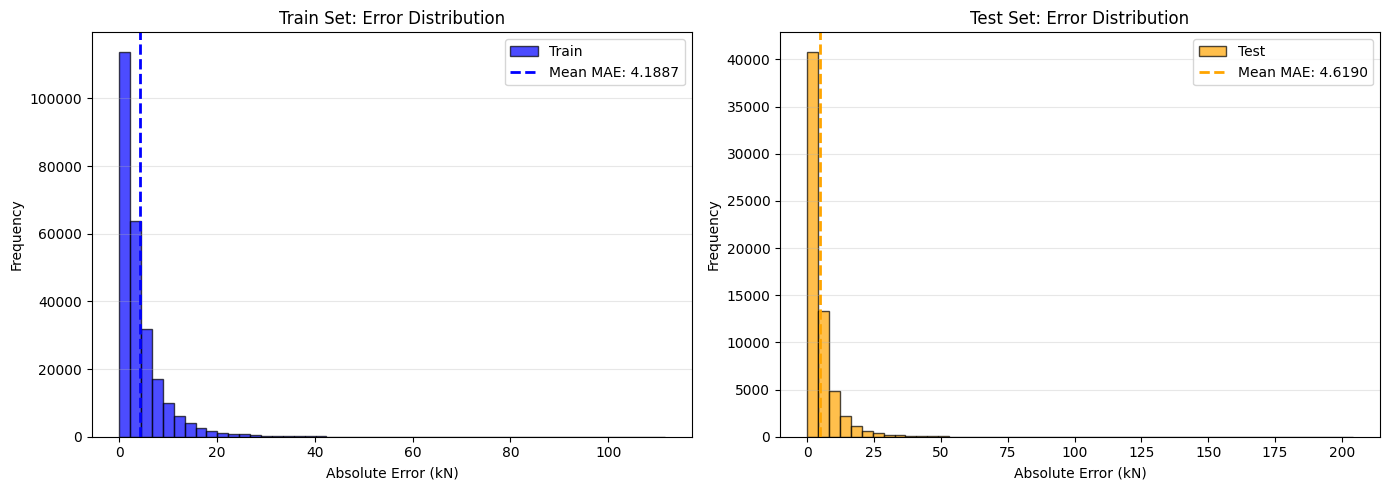

✅ Error distribution plots generated.


In [29]:
# Error distribution plots (uses residuals/MAE computed in previous diagnostics cell)
required_objs = ["train_residuals", "test_residuals", "train_mae", "test_mae"]
missing_objs = [name for name in required_objs if name not in globals()]
if missing_objs:
    raise NameError(
        f"Missing required objects in memory: {missing_objs}. Run the previous diagnostics cell first."
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Error distribution (train set)
ax = axes[0]
train_errors = np.abs(train_residuals)
ax.hist(train_errors, bins=50, alpha=0.7, edgecolor="black", color="blue", label="Train")
ax.axvline(train_mae, color="blue", linestyle="--", lw=2, label=f"Mean MAE: {train_mae:.4f}")
ax.set_xlabel("Absolute Error (kN)")
ax.set_ylabel("Frequency")
ax.set_title("Train Set: Error Distribution")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# 2. Error distribution (test set)
ax = axes[1]
test_errors = np.abs(test_residuals)
ax.hist(test_errors, bins=50, alpha=0.7, edgecolor="black", color="orange", label="Test")
ax.axvline(test_mae, color="orange", linestyle="--", lw=2, label=f"Mean MAE: {test_mae:.4f}")
ax.set_xlabel("Absolute Error (kN)")
ax.set_ylabel("Frequency")
ax.set_title("Test Set: Error Distribution")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
error_dist_fig = fig  # Used later by save_evaluation(...)
plt.show()

print("✅ Error distribution plots generated.")

In [ ]:
import importlib
import config
import model_evaluation

# Ensure latest model_evaluation.py changes are loaded in notebook kernel
importlib.reload(model_evaluation)

model_artifact_stem = globals().get("artifact_stem", globals().get("PRETRAINED_MODEL_PREFIX", "unknown_model"))
architecture_summary = {
    "model_class": "TrussEdgeGNN",
    "node_in_dim": NODE_FEATURE_DIM,
    "hidden_dim": 128,
    "edge_count": EDGE_COUNT,
    "device": str(device),
    "node_feature_dim": NODE_FEATURE_DIM,
    "dataset_version": DATASET_VERSION,
    "dataset_label": STRICT_DATASET_LABEL,
}
experiment_notes = (
    f"USE_PRETRAINED={USE_PRETRAINED}; "
    f"USE_NEWEST={USE_NEWEST}; "
    f"USE_TRAINING_TIME_LIMIT={USE_TRAINING_TIME_LIMIT}; "
    f"source_csv={CSV_FILE}"
)

# SAVE ALL EVALUATION RESULTS TO FILE
saved_files = model_evaluation.save_evaluation(
    model_prefix=model_artifact_stem,
    dataset_name=CSV_FILE,
    metrics=metrics,
    pred_residuals_fig=pred_residuals_fig,
    error_dist_fig=error_dist_fig,
    training_visuals_fig=globals().get("training_visuals_fig"),
    node_count=NODE_COUNT,
    edge_count=EDGE_COUNT,
    export_path=config.SM_DATA_PATH,
    status=status,
    run_id=RUN_ID,
    artifact_stem=model_artifact_stem,
    learning_rate=LEARNING_RATE,
    epochs=EPOCHS,
    final_val_r2=final_val_r2,
    strict_dataset_label=STRICT_DATASET_LABEL,
    source_dataset_path=str(config.GH_DATA_PATH / CSV_FILE),
    architecture_summary=architecture_summary,
    experiment_notes=experiment_notes,
    train_split_ratio=TRAIN_SPLIT_RATIO,
    random_seed=RANDOM_SEED,
    source_notebook="c21_surrogate_model_training.ipynb",
)



Saving evaluation results for: data_3.1_0000

Metrics saved: metrics_20260402_124110.json
Predictions plot saved: 01_predictions_residuals_20260402_124110.png
Error distribution saved: 02_error_distribution_20260402_124110.png
Training diagnostics saved: 03_training_diagnostics_20260402_124110.png
README saved: README.md

All evaluation files saved to:
   C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\02_surrogate_model_data\data_3.1_0000_2026-04-02_124110



## Interpretation Guide

### What to look for:

**OVERFITTING** 🔴 (Train performs much better than Test):
- Train R² >> Test R² (gap > 0.05)
- Train residuals are much smaller than test residuals
- Test error histogram has a heavier right tail
- Predictions vs Actual scatter: train points closer to red line than test points

**UNDERFITTING** 🔴 (Both train and test perform poorly):
- Both R² scores are low (< 0.7)
- Both residuals show large systematic patterns
- Both predictions scatter far from the red diagonal line
- High MAE/RMSE on both train and test

**GOOD FIT** ✅ (Train and Test perform similarly):
- Train and Test R² are close (gap < 0.05)
- Both residuals are centered around 0 with similar spread
- Both scatter plots show points close to diagonal line
- Error distributions are similar and centered

### Remedies:

If **Overfitting**:
- **Gather more training data** (most effective long-term solution—model memorizes less with more diverse samples)
- Add dropout layers to the model
- Increase weight decay (L2 regularization)
- Use early stopping on validation loss
- Try reducing model hidden_dim (e.g., 128 → 64)

If **Underfitting**:
- Increase hidden_dim (e.g., 128 → 256)
- Add more GNN layers
- Train for more epochs
- Check if the model has enough capacity for the problem

If **Good Fit**: ✅ Deploy and use in downstream tasks!